# Chapter 2: End to End Machine Learning Project

The main steps involved in an end to end machine learning project are as follows:
1. Look at the bigger picture.
2. Get the data.
3. Discover and visualize the data to gain insights.
4. Prepare the data for machine learning algorithms.
5. Select a model and train it.
6. Fine-tune your model.
7. Present your solution.
8. Launch, monitor, and maintain your system.

## Look at the bigger picture

Our task is to use the California housing data to predict the median house value in a district which depends on various factors like median income, housing median age, population of each block group.

* Block group: A block group is a geographical unit used by the United States Census Bureau. It is a subdivision of a census tract and typically contains between 600 and 3,000 people. Block groups are used for statistical purposes and are the smallest geographic units for which the Census Bureau publishes sample data.

## Frame the problem

Now I can ask boss or client: What do they expect from the model? What is the business objective here? What are we trying to achieve?

Asking this question is important because the answer of this question will decide what models do we use, what type of data do we gather, how do we automate system and even how do we evaluate and monitor the system.

Now the boss can reply that the model will be used to predict a house price in order to see if it's worth investing in that area. And also the output of this model can be fed into another model as a signal so the prediction of this model should be kept as accurate as possible in real scenarios (not just testing environment).

The next question that you ask your boss might be: What's the current way of doing it. The boss replies that currently a team of experts use the data to predict the house price, which is costly and time consuming and also if the data isn't available. Then they have to use complex rules in order to predict the median house price.

He also tells us that their prediction is wrong sometimes by the margin of 30%.

Now we get an idea of what things should we improve and how do we evaluate our performance.

**Data Pipeline**

Data pipeline is a sequence of data processing components which usually run asynchronously, they pull in chunk of data and then spit out a result which can be stored in Data Store. Now, the data store is usually the interface between different data processing components.

This setup can be easily comprehended using Data Flow Graph.

On one hand, it makes the system very easy to grasp.

Also it makes sure that our architecture is quite robust, if a component breaks, the other components can just keep on working by using the last correct output of the broken component.

But on the other hand, a system (if unmonitored) can go stale over time and it's performance might degrade.

**Some questions to ask**

1. Is it a supervised, semi-supervised or un-supervised machine learning task.
2. Should we use online-learning or batch-learning technique.
3. Is it a classification or regression task.

The answer to those questions would be that it is a __multiple regression__ (since we are using multiple variables to predict some value), __univariate regression__ (since we are trying to predict only one value), __supervised__ and __batch-learning__ task.

### Select a performance measure

Our next step is to use a performance measure. Now for regression problems the performance measure is usually the Root Mean Squared Error.

**NOTE** Usually Root Mean Square Error is the preferred performance evaluator for regression problems, but it is very sensitive to outliers, so if we have a lot of outliers in our data, we might want to switch to the __ABSOLUTE MEAN ERROR__ instead.

Both RSME and MAE are ways to find distance between two vectors: __vector of predictions and vector of target variables__.

MAE is __l1 norm__ and it cares about errors equally.
If a prediction is 10 times off, the prediction is simply 10 times worse.

It is also called __Manhattan Norm__.

It is denoted by `|| . ||1`.

RSME is __l2 norm__ and it squares the errors thus first making them positive, and here the script changes a little bit.

Here if a prediction is 10 times off, after squaring and doing all the math it might come off as 100 times worse prediction, so a huge penalty score.

It is also called `Euclidean Norm`.

It is denoted by `|| . ||2`.

### Checking the assumptions

Now here's the thing, we made an assumption that the downstream model will take actual prices as input from this model. But what if the model actually takes the prices and convert them into _expensive_, _medium_ and _cheap_ categories.

If that's the case, actually getting the prices right is not the main concern, getting the right category is. In that case, this would clearly be a classification task.

## Get data

Now we should always try to automate as many things in data downloading as possible for two reasons. If the data is regularly updated, we can just call a function and get the updated data or schedule it to run at appropriate times. For second reason, it is easy to run scripts on various computers.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import tarfile
import pandas as pd

def load_download_data():
    repo_root = Path.cwd().resolve()
    data_dir = repo_root / "data"
    data_dir.mkdir(parents=True, exist_ok=True)

    tarball_path = data_dir / "housing.tgz"
    csv_path = data_dir / "housing" / "housing.csv"

    if not tarball_path.exists():
        url = "https://www.github.com/ageron/data/raw/main/housing.tgz"
        urlretrieve(url, tarball_path)

    if not csv_path.exists():
        with tarfile.open(tarball_path) as housing_dataset:
            housing_dataset.extractall(data_dir)

    return pd.read_csv(csv_path)

In [2]:
housing_df = load_download_data()

In [3]:
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

The dataset contains 20 thousand rows. All of them are numerical except one `ocean_proximity` which is of type `str`.

The `ocean_proximity` column upon seeing the result of `value_counts()` method was concluded to be a categorical column.

There are null elements in `total_bedrooms` feature.

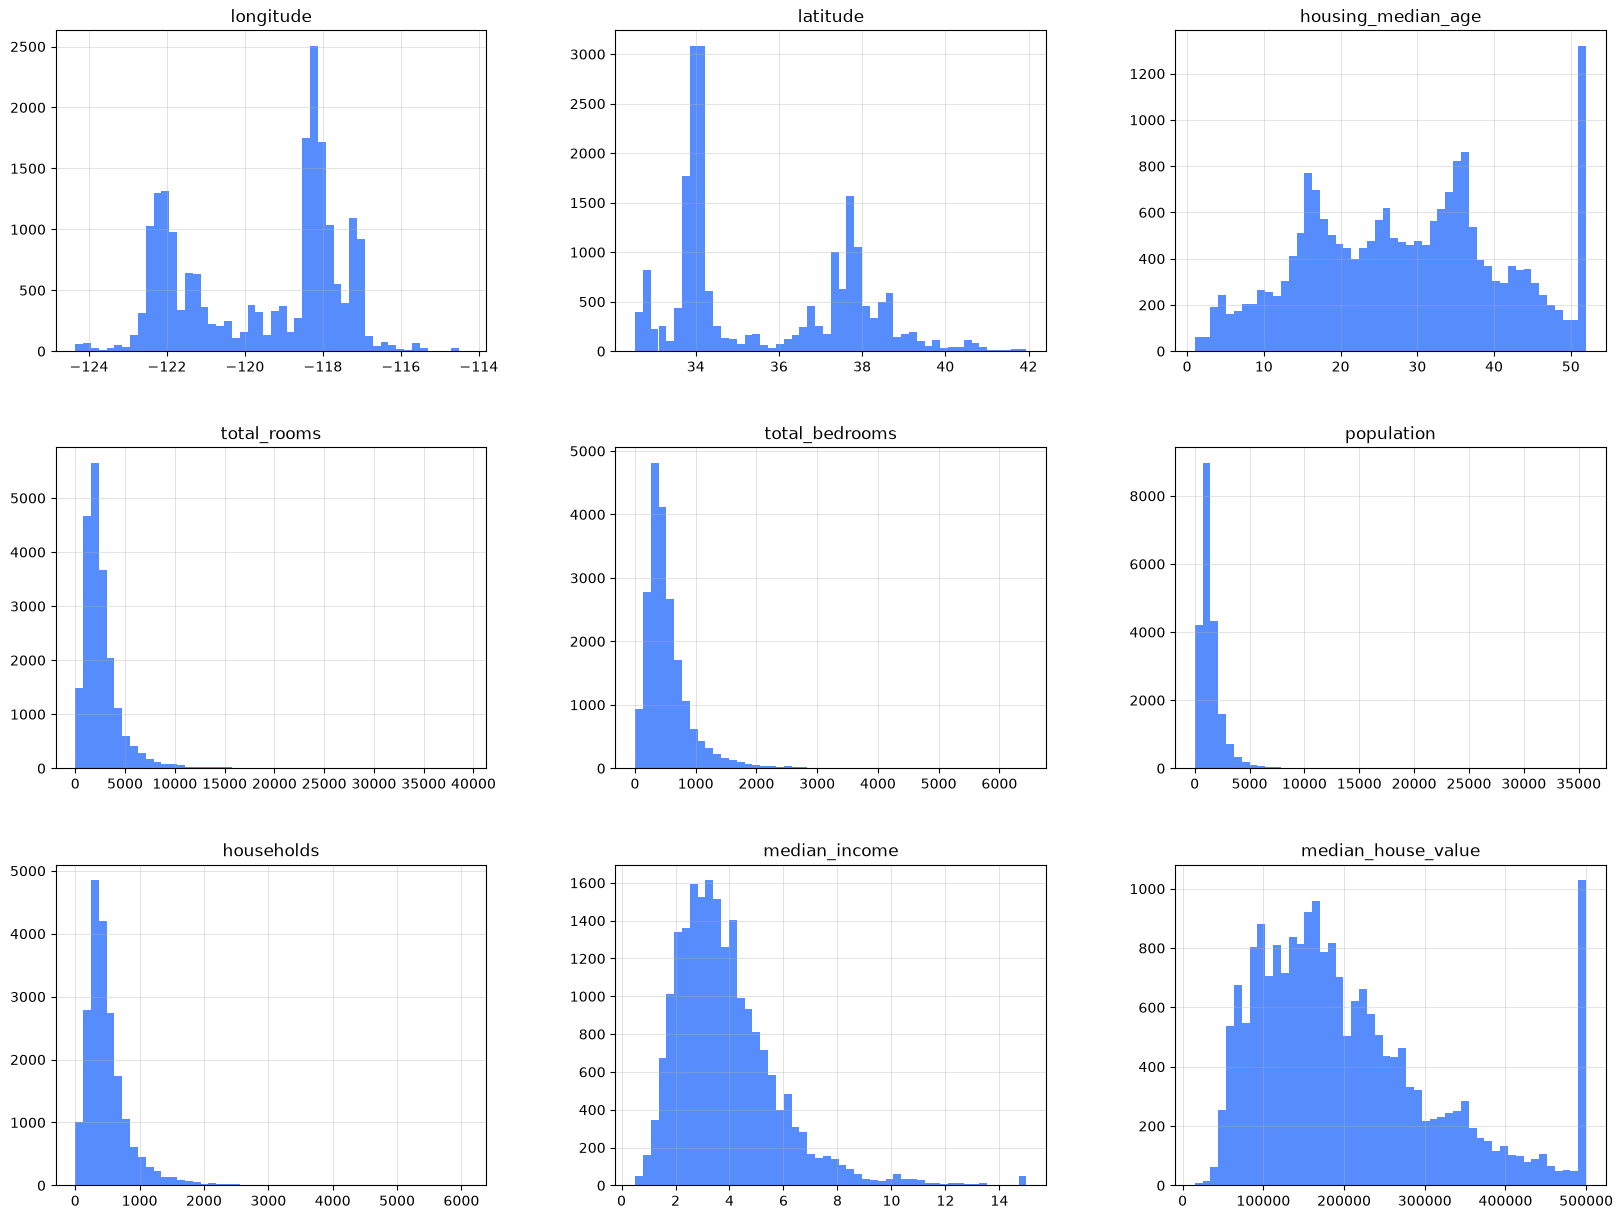

In [7]:
import matplotlib.pyplot as plt

housing_df.hist(bins=50, figsize=(20, 15))
plt.show()

The conclusion is that many of the column are actually right-skewed.

In [8]:
def get_skew_value(df: pd.DataFrame):
    res_df = {}
    for col in df.select_dtypes(include="number").columns:
        skew_val = df[col].skew()
        skew_val_tag = "positive" if skew_val > 0 else "negative" if skew_val < 0 else "no skew"
        res_df[col] = [skew_val, skew_val_tag]

    return pd.DataFrame(res_df)

In [9]:
get_skew_value(housing_df)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-0.297801,0.465953,0.060331,4.147343,3.459546,4.935858,3.410438,1.646657,0.977763
1,negative,positive,positive,positive,positive,positive,positive,positive,positive


All the features are positively skewed except `longitude` which is *negatively* skewed.

In [10]:
housing_df['median_income'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

The median salary was pre-processed and every factor was divided by `10000`.

In machine learning, we often work with these already pre-processed data.

### Check if some features have been capped.

The `housing_median_age` and `median_house_value` were capped.

Now we need to find if this is a problem or not, cause our Machine Learning model might learn that the housing median age or housing medain value never go up beyond certain limit and then try to memorize that.

The attributes overall have very different scales, for example number of bedrooms and housing median income have very different scales.

### Converting Continuous Feature Columns into Categorical Ones


Upon talking to researchers they told us that the median salary is a very important feature and you should sample data so that this is representative of every category (that is also a task to do first).

In [11]:
import numpy as np

housing_df['median_house_cat'] = pd.cut(housing_df["median_income"], bins=[0, 1.5, 3, 4.5, 6, np.inf], labels=[1, 2, 3, 4, 5])

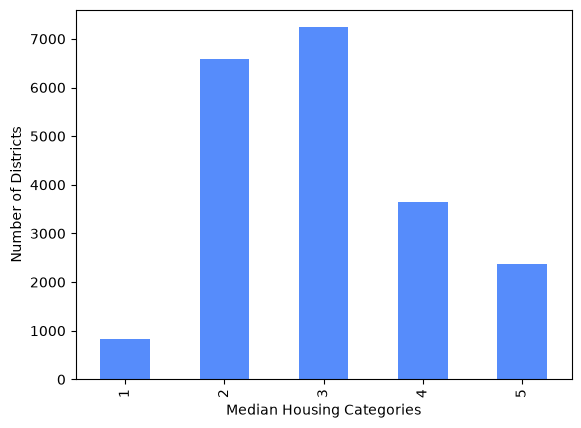

In [14]:
median_house_cat_counts = housing_df['median_house_cat'].value_counts().sort_index()
median_house_cat_counts.plot(kind='bar')
plt.xlabel("Median Housing Categories")
plt.ylabel("Number of Districts")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(housing_df, test_size=0.2, random_state=42, stratify=housing_df['median_house_cat'])

In [17]:
housing_df['median_house_cat'].value_counts() / len(housing_df['median_house_cat'])

median_house_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [19]:
test_data['median_house_cat'].value_counts() / len(test_data['median_house_cat'])

median_house_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [20]:
train_data['median_house_cat'].value_counts() / len(train_data['median_house_cat'])

median_house_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

As we can see the stratified sampling was successful, both the test data and training data represent the classes pretty much as it was in the full housing dataset.

Now as we know that the category column was purely for the stratified sampling and we won't use that column any more, we can drop that column from both the test data set and train dataset.

In [21]:
for _dataset in [test_data, train_data]:
    _dataset.drop('median_house_cat', axis=1, inplace=True)

In [24]:
test_data.info()

<class 'pandas.DataFrame'>
Index: 4128 entries, 3905 to 3455
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           4128 non-null   float64
 1   latitude            4128 non-null   float64
 2   housing_median_age  4128 non-null   float64
 3   total_rooms         4128 non-null   float64
 4   total_bedrooms      4089 non-null   float64
 5   population          4128 non-null   float64
 6   households          4128 non-null   float64
 7   median_income       4128 non-null   float64
 8   median_house_value  4128 non-null   float64
 9   ocean_proximity     4128 non-null   str    
dtypes: float64(9), str(1)
memory usage: 354.8 KB


In [25]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.4 MB


The category feature has been dropped successfully.